In [76]:
from line_follower_detailed import LineFollower

In [77]:
class Config:
    OVERLAY = False

In [78]:
config = Config()
with open("my-config.next.py", 'r') as file:
    exec(file.read(), globals(), config.__dict__)

In [79]:
config.__dict__

{'CAMERA_TYPE': 'PICAM',
 'IMAGE_W': 320,
 'IMAGE_H': 240,
 'DRIVE_TRAIN_TYPE': 'PWM_STEERING_THROTTLE',
 'PWM_STEERING_THROTTLE': {'PWM_STEERING_PIN': 'PCA9685.1:40.1',
  'PWM_STEERING_SCALE': 1.0,
  'PWM_STEERING_INVERTED': False,
  'PWM_THROTTLE_PIN': 'PCA9685.1:40.0',
  'PWM_THROTTLE_SCALE': 1.0,
  'PWM_THROTTLE_INVERTED': False,
  'STEERING_LEFT_PWM': 455,
  'STEERING_RIGHT_PWM': 264,
  'THROTTLE_FORWARD_PWM': 383,
  'THROTTLE_STOPPED_PWM': 350,
  'THROTTLE_REVERSE_PWM': 0},
 'CV_CONTROLLER_MODULE': 'line_follower_detailed',
 'CV_CONTROLLER_CLASS': 'LineFollower',
 'CV_CONTROLLER_INPUTS': ['cam/image_array'],
 'CV_CONTROLLER_OUTPUTS': ['pilot/steering',
  'pilot/throttle',
  'cv/image_array'],
 'CV_CONTROLLER_CONDITION': 'run_pilot',
 'SCAN_Y': 80,
 'SCAN_HEIGHT': 100,
 'COLOR_THRESHOLD_LOW': (20, 102, 131),
 'COLOR_THRESHOLD_HIGH': (47, 255, 255),
 'EDGE_COLOR_THRESHOLD_LOW': (0, 0, 203),
 'EDGE_COLOR_THRESHOLD_HIGH': (179, 30, 255),
 'TARGET_PIXEL': 160,
 'TARGET_THRESHOLD': 10,

In [80]:
## Override some of the config values


In [81]:
from simple_pid import PID

# Initialize PID controller
pid = PID(Kp=0.1, Ki=0.01, Kd=0.005, setpoint=0)

In [82]:
from matplotlib import pyplot as plt
import cv2

In [83]:
def show_rgb_image(bgr_image):
    # Convert the image from BGR to RGB
    cpy = bgr_image.copy()
    image_rgb = cv2.cvtColor(cpy, cv2.COLOR_BGR2RGB)
    plt.imshow(image_rgb)
    plt.axis('off')  # Turn off axis
    plt.show()

In [84]:
def show_rgb_image(image_rgb):
    plt.imshow(image_rgb)
    plt.axis('off')  # Turn off axis
    plt.show()

In [85]:
image_path = '../../../../vision/donkeypi2_test_1.png'
bgr_image = cv2.imread(
    image_path
)  

if bgr_image is None:
    raise ValueError(f"Could not read image from path: {image_path}")
print(
    f"Image size: {bgr_image.shape[1]}x{bgr_image.shape[0]}, "
)
# Resize the frame to the specified dimensions
bgr_image_resized = cv2.resize(bgr_image, (config.__dict__['IMAGE_W'], config.__dict__['IMAGE_H']))
print(f"Image resized: {bgr_image_resized.shape[1]}x{bgr_image_resized.shape[0]}, ")
# Convert the frame from BGR to RGB color space
image_rgb = cv2.cvtColor(bgr_image_resized, cv2.COLOR_BGR2RGB)

Image size: 670x503, 
Image resized: 320x240, 


In [86]:
line_follower = LineFollower(pid, config)

In [87]:
steering, throttle, run_image = line_follower.run(image_rgb)
assert run_image is not None
assert run_image.shape == image_rgb.shape


Error in line detection: No lines detected


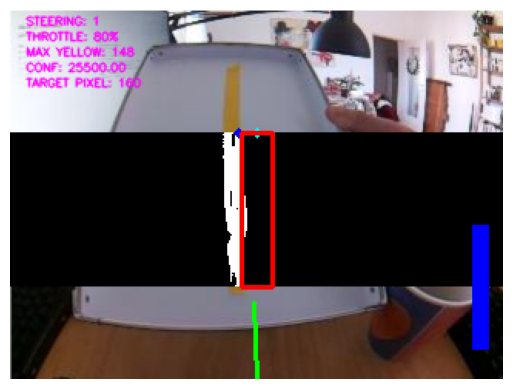

In [88]:
# Just try running the entire pipeline
show_rgb_image(run_image)

## Now lets break it down

In [89]:
roi_mask = line_follower.get_roi_mask(image_rgb)

In [90]:
max_yellow, confidence = line_follower.get_i_color(
    cv2.cvtColor(image_rgb.copy(), cv2.COLOR_RGB2GRAY),
)
max_yellow, confidence  

(0, 47432)

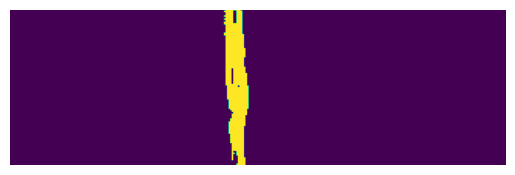

In [91]:
show_rgb_image(roi_mask)

In [92]:
# Save the mask to a file for analysis  
# cv2.imwrite('mask.png', cv2.cvtColor(roi_mask, cv2.COLOR_RGB2BGR))

True

In [93]:
final_image = line_follower.overlay_display(
    image_rgb,
    roi_mask,
    max_yellow,
    confidence,
    line_follower.target_pixel,
)

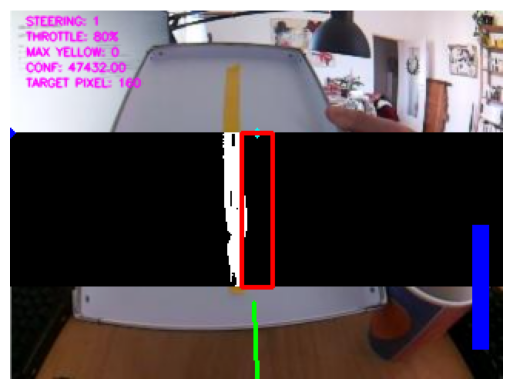

In [94]:
show_rgb_image(final_image)

# Lets try some hough stuff

In [95]:
line_detection_results = line_follower.run_line_detection_on_hsv_mask(roi_mask)
line_detection_results

Exception: No lines detected

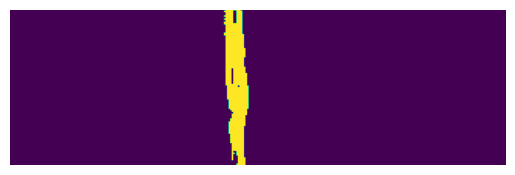

In [96]:
show_rgb_image(roi_mask)

## Try manually doing hough transform on the image

In [97]:
config.__dict__

{'CAMERA_TYPE': 'PICAM',
 'IMAGE_W': 320,
 'IMAGE_H': 240,
 'DRIVE_TRAIN_TYPE': 'PWM_STEERING_THROTTLE',
 'PWM_STEERING_THROTTLE': {'PWM_STEERING_PIN': 'PCA9685.1:40.1',
  'PWM_STEERING_SCALE': 1.0,
  'PWM_STEERING_INVERTED': False,
  'PWM_THROTTLE_PIN': 'PCA9685.1:40.0',
  'PWM_THROTTLE_SCALE': 1.0,
  'PWM_THROTTLE_INVERTED': False,
  'STEERING_LEFT_PWM': 455,
  'STEERING_RIGHT_PWM': 264,
  'THROTTLE_FORWARD_PWM': 383,
  'THROTTLE_STOPPED_PWM': 350,
  'THROTTLE_REVERSE_PWM': 0},
 'CV_CONTROLLER_MODULE': 'line_follower_detailed',
 'CV_CONTROLLER_CLASS': 'LineFollower',
 'CV_CONTROLLER_INPUTS': ['cam/image_array'],
 'CV_CONTROLLER_OUTPUTS': ['pilot/steering',
  'pilot/throttle',
  'cv/image_array'],
 'CV_CONTROLLER_CONDITION': 'run_pilot',
 'SCAN_Y': 80,
 'SCAN_HEIGHT': 100,
 'COLOR_THRESHOLD_LOW': (20, 102, 131),
 'COLOR_THRESHOLD_HIGH': (47, 255, 255),
 'EDGE_COLOR_THRESHOLD_LOW': (0, 0, 203),
 'EDGE_COLOR_THRESHOLD_HIGH': (179, 30, 255),
 'TARGET_PIXEL': 160,
 'TARGET_THRESHOLD': 10,

In [98]:
from dataclasses import dataclass

@dataclass
class HoughLineDetectionParams:
    rho: int
    theta: int
    threshold: int
    min_line_length: int
    max_line_gap: int

In [100]:
hough_params = HoughLineDetectionParams(
    rho=config.__dict__['HOUGH_RHO'],
    theta=config.__dict__['HOUGH_THETA'],
    threshold=config.__dict__['HOUGH_THRESHOLD'],
    min_line_length=config.__dict__['HOUGH_MIN_LINE_LENGTH'],
    max_line_gap=config.__dict__['HOUGH_MAX_LINE_GAP'],
)
lines = cv2.HoughLinesP(
    roi_mask,
    rho=hough_params.rho,
    theta=hough_params.theta,
    threshold=hough_params.threshold,
    minLineLength=hough_params.min_line_length,
    maxLineGap=float(hough_params.max_line_gap),
)

In [101]:
type(lines)

numpy.ndarray

In [102]:
lines

array([[[143,  96, 143,   0]],

       [[146,  99, 146,   0]],

       [[149,  99, 149,   1]],

       [[140,  57, 140,   0]],

       [[144,  92, 144,   0]],

       [[142,  85, 142,   0]],

       [[151,  74, 151,  25]],

       [[148,  99, 148,   0]],

       [[150,  99, 150,  16]],

       [[145,  90, 145,   0]],

       [[139,  48, 139,   0]],

       [[141,  79, 141,   0]],

       [[147,  99, 147,   0]]], dtype=int32)

In [103]:
import numpy as np

In [104]:
bgr_image.shape

(503, 670, 3)

In [105]:
# Expand the dimensions of the mask to match the image shape to three color channels
mask_exp = np.stack((roi_mask,) * 3, axis=-1)

i_slice = config.__dict__['SCAN_Y']
scan_height = config.__dict__['SCAN_HEIGHT']

i_slice, scan_height

(80, 100)

## Show only the original region of interest

In [106]:
detect_section = image_rgb[i_slice : i_slice + scan_height, :, :]

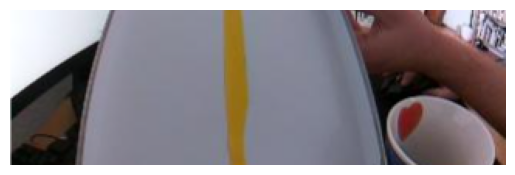

In [107]:
show_rgb_image(detect_section)

In [108]:
def get_center_mask(self, cam_img: np.ndarray) -> np.ndarray:
    """
    Get the mask of the center region of the image based on the color thresholds.
    """
    # take a horizontal slice of the image
    i_slice = self.scan_y

    # Get all the pixels in the slice from the image from the top to the bottom of the
    # scan to the scan height with all horizontal pixels and all color channels
    scan_line = cam_img[i_slice : i_slice + self.scan_height, :, :]

    # convert to HSV color space
    img_hsv = cv2.cvtColor(scan_line, cv2.COLOR_RGB2HSV)

    # make a mask of the colors in our range we are looking for
    center_mask = cv2.inRange(img_hsv, self.color_thr_low, self.color_thr_hi)
    return center_mask

In [109]:
roi_mask = line_follower.get_roi_mask(image_rgb)

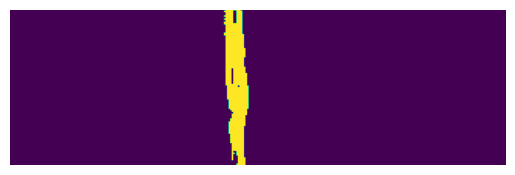

In [110]:
show_rgb_image(roi_mask)

In [111]:
# Apply Gaussian blur to reduce noise
kernal_size = line_follower.canny_params.gaussian_blur_kernal_size
kernal = (kernal_size, kernal_size)
sigma_standard_deviation = 0

blurred = cv2.GaussianBlur(roi_mask, kernal, sigma_standard_deviation)

# Perform Canny edge detection
edges = cv2.Canny(
    blurred, line_follower.canny_params.low_threshold, line_follower.canny_params.high_threshold
)


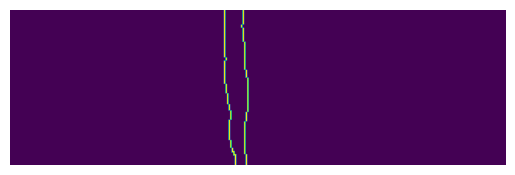

In [116]:
show_rgb_image(edges)

In [117]:
hough_params = line_follower.hough_params

In [118]:
lines = cv2.HoughLinesP(
    edges,
    rho=hough_params.rho,
    theta=hough_params.theta,
    threshold=hough_params.threshold,
    minLineLength=hough_params.min_line_length,
    maxLineGap=hough_params.max_line_gap,
)

In [119]:
lines

In [120]:
import numpy as np

In [122]:
lines_image = np.copy(cv2.cvtColor(roi_mask, cv2.COLOR_GRAY2BGR))
line_color = (0, 255, 0) ## RGB GREEN
lines_image.shape

(100, 320, 3)

In [123]:
for line in lines:
    for x1, y1, x2, y2 in line:
        cv2.line(lines_image, (x1, y1), (x2, y2), line_color, 2)
lines

TypeError: 'NoneType' object is not iterable

In [ ]:
show_rgb_image(lines_image)

## Get average line

In [124]:
lines_parameters = []

for line in lines:
    x1, y1, x2, y2 = line.reshape(4)
    slope, intercept = np.polyfit((x1, x2), (y1, y2), 1)
    lines_parameters.append((slope, intercept))

TypeError: 'NoneType' object is not iterable

In [ ]:
lines_parameters

In [ ]:
# Get the average of the lines
average_slope_intercept = np.average(lines_parameters, axis=0)
average_slope_intercept

In [ ]:
roi_mask.shape

In [ ]:
def make_coordinates(image: np.ndarray, line_parameters: np.ndarray) -> np.ndarray:
    slope, intercept = line_parameters
    y1 = image.shape[0]
    ratio_up_the_screen = 1 / 5
    y2 = int(y1 * (ratio_up_the_screen))
    x1 = int((y1 - intercept) / slope)
    x2 = int((y2 - intercept) / slope)
    return np.array([x1, y1, x2, y2])

In [ ]:
slope_coodinates_for_image = make_coordinates(roi_mask, average_slope_intercept)
slope_coodinates_for_image

In [ ]:
average_angle_img = np.copy(cv2.cvtColor(roi_mask, cv2.COLOR_GRAY2BGR))

In [ ]:
average_angle_img.shape, slope_coodinates_for_image

In [ ]:
x1, y1, x2, y2 = slope_coodinates_for_image
center_line_angle_color_rgb = (0, 255, 255)
average_angle_img = cv2.line(average_angle_img, (x1, y1), (x2, y2), center_line_angle_color_rgb, 2)

## Lets look at the picture though each step

In [ ]:
show_rgb_image(detect_section)

In [ ]:
show_rgb_image(roi_mask)

In [ ]:
show_rgb_image(lines_image)

In [ ]:
print(average_angle_img.shape)
show_rgb_image(average_angle_img)

In [ ]:
import math

x1, y1, x2, y2 = slope_coodinates_for_image

# Calculate the angle in radians
angle_radians = math.atan2(y2 - y1, x2 - x1)

# Convert the angle from radians to degrees
angle_degrees = math.degrees(angle_radians)

# Adjust the angle so that an upward-pointing line has an angle of 0 degrees
if angle_degrees < -90:
    angle_degrees += 180
elif angle_degrees > 90:
    angle_degrees -= 180

print(f"Angle of the line: {angle_degrees:.2f} degrees")